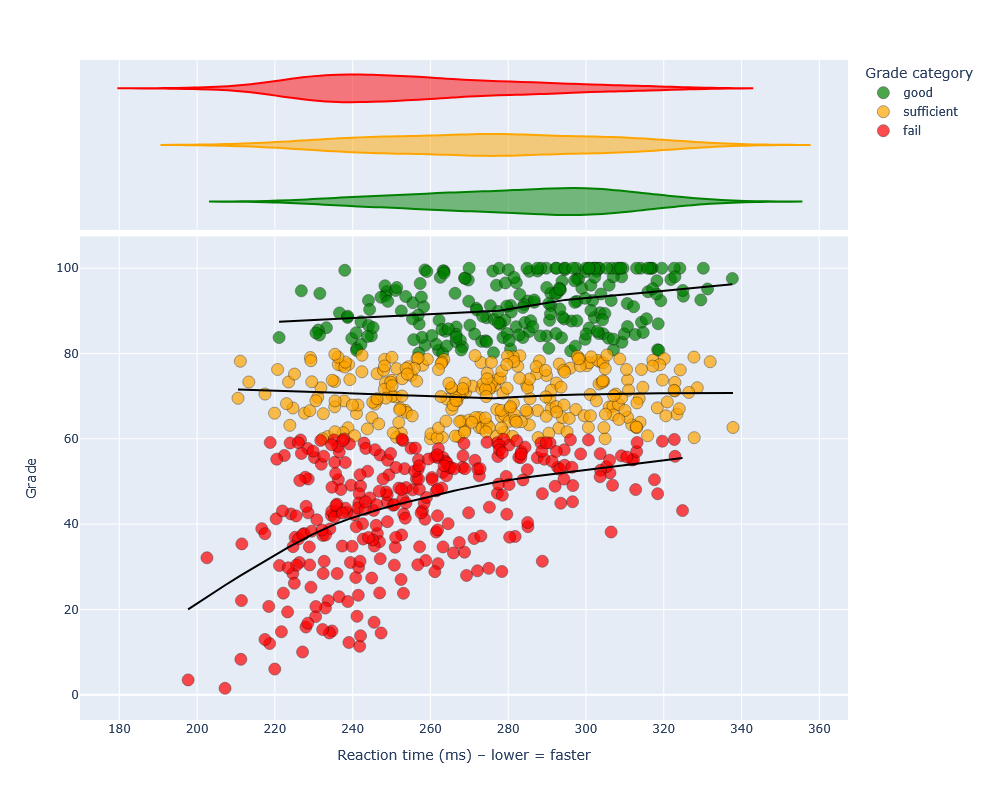

In [4]:
import pandas as pd
import plotly.express as px
import numpy as np

df = pd.read_csv("../../data/Gaming_Academic_Performance.csv")

df_filtered = df[df["grades"] <= 100].copy()

conditions = [
    df_filtered["grades"] >= 80,
    df_filtered["grades"] >= 60,
]
choices = ["good", "sufficient"]

df_filtered["grade_category"] = np.select(conditions, choices, default="fail")

if len(df_filtered) > 800:
    df_small = df_filtered.sample(n=800, random_state=0)
else:
    df_small = df_filtered.copy()

fig = px.scatter(
    df_small,
    x="reaction_time_ms",
    y="grades",
    color="grade_category",
    hover_data=[
        "gaming_hours",
        "study_hours",
        "reaction_time_ms",
        "grades",
        "grade_category",
    ],
    labels={
        "reaction_time_ms": "Reaction time (ms)",
        "grades": "Grade",
        "gaming_hours": "Gaming hours/week",
        "grade_category": "Grade category",
        "study_hours": "Study hours/week",
    },
    color_discrete_map={
        "fail": "red",
        "sufficient": "orange",
        "good": "green",
    },
    marginal_x="violin",
    trendline="lowess",
    trendline_color_override="black",
    width=1000,
    height=800,
)

fig.update_traces(
    marker=dict(size=12, opacity=0.7, line=dict(width=0.5, color="black"))
)

fig.update_layout(
    xaxis_title="Reaction time (ms) – lower = faster",
    yaxis_title="Grade",
    legend_title_text="Grade category",
)

fig.show()